# ⌨️ Summary ⌨️

In this notebook we will go over a number of ensemble methods in which we look ensembling the output of binary classification probabilities:
1. Hill Climbing (OOF ensembling) 
1. Scipy Optimize (Nelder-Mead)
1. Logistic Regression Ensembling
1. Mean Ensembling 
1. Weighted Ensembling

We will be using a scoring method to measure the training prediction as a baseline in many of the above ensemble methods. This notebook uses **Logloss** as the scoring method which we try to minimize 

# 📩 Import Libraries & Data  📩

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.metrics import * 
import os 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LassoLarsCV

from scipy.optimize import minimize

In [2]:
OVERFIT_THRESHOLD = 0.4  # see section, anythin less than this score will be removed

folds = 5

TYPE = "Classification" #Regression

In [3]:
y = pd.read_csv("../input/tabular-playground-series-nov-2022/train_labels.csv",index_col = 0)
y = np.ravel(y)

PATH = '../input/tps-nov-best-dataset/'
PATH = PATH+"/"
FILES = os.listdir(PATH)
FILES

['test_predictions (92).csv',
 'train_predictions (88).csv',
 'train_predictions (2).csv',
 'train_predictions (77).csv',
 'train_predictions (118).csv',
 'train_predictions (102).csv',
 'train_predictions (74).csv',
 'test_predictions (124).csv',
 'test_predictions (123).csv',
 'test_predictions (41).csv',
 'test_predictions (14).csv',
 'train_predictions (41).csv',
 'train_predictions (110).csv',
 'train_predictions (30).csv',
 'test_predictions (49).csv',
 'train_predictions (98).csv',
 'test_predictions (34).csv',
 'train_predictions (63).csv',
 'test_predictions (21).csv',
 'test_predictions (107).csv',
 'train_predictions (92).csv',
 'train_predictions (108).csv',
 'train_predictions (69).csv',
 'train_predictions (57).csv',
 'train_predictions (93).csv',
 'test_predictions (17).csv',
 'train_predictions (51).csv',
 'test_predictions (37).csv',
 'train_predictions (42).csv',
 'train_predictions (39).csv',
 'test_predictions (139).csv',
 'test_predictions (33).csv',
 'train_predic

# 📋 Create Datasets 📋
* We have a set of train prediction files (csv) and test predictions 
* We will load these into a list and read them into a Dataframe

In [4]:
train_files = [file for file in FILES if "train" in file]
test_files = [file for file in FILES if "test" in file]
print("Length train:",len(train_files),"length test:", len(test_files))

Length train: 142 length test: 142


In [5]:
def sort_func(file):
    return int(file.split("(")[1].split(")")[0])

train_files.sort(key=sort_func)
test_files.sort(key=sort_func)
train_files

['train_predictions (0).csv',
 'train_predictions (1).csv',
 'train_predictions (2).csv',
 'train_predictions (3).csv',
 'train_predictions (4).csv',
 'train_predictions (5).csv',
 'train_predictions (6).csv',
 'train_predictions (7).csv',
 'train_predictions (8).csv',
 'train_predictions (9).csv',
 'train_predictions (10).csv',
 'train_predictions (11).csv',
 'train_predictions (12).csv',
 'train_predictions (13).csv',
 'train_predictions (14).csv',
 'train_predictions (15).csv',
 'train_predictions (16).csv',
 'train_predictions (17).csv',
 'train_predictions (18).csv',
 'train_predictions (19).csv',
 'train_predictions (20).csv',
 'train_predictions (21).csv',
 'train_predictions (22).csv',
 'train_predictions (23).csv',
 'train_predictions (24).csv',
 'train_predictions (25).csv',
 'train_predictions (26).csv',
 'train_predictions (27).csv',
 'train_predictions (28).csv',
 'train_predictions (29).csv',
 'train_predictions (30).csv',
 'train_predictions (31).csv',
 'train_prediction

In [6]:
train_preds = pd.DataFrame(np.zeros(( len(y),len(train_files) )))
test_preds = pd.DataFrame(np.zeros(( len(y),len(test_files) )))

for i,file in enumerate(train_files): 

    train_preds.iloc[:,i] = np.array(pd.read_csv(PATH+train_files[i], index_col =0 ))
    test_preds.iloc[:,i] = np.array(pd.read_csv(PATH+test_files[i], index_col =0 ))
    
train_preds

0         1         2         3         4         5         6    \
0      0.676784  0.632422  0.631255  0.631451  0.683147  0.284155  0.627395   
1      0.582280  0.509337  0.566275  0.571213  0.579584  0.175430  0.573932   
2      0.654823  0.585373  0.584786  0.586727  0.657968  0.252632  0.595650   
3      0.657671  0.593208  0.590959  0.588793  0.657673  0.236703  0.598767   
4      0.698916  0.675133  0.664984  0.663498  0.697673  0.337182  0.657022   
...         ...       ...       ...       ...       ...       ...       ...   
19995  0.700214  0.665890  0.614082  0.612955  0.702266  0.303767  0.627583   
19996  0.600755  0.553926  0.573281  0.574635  0.603384  0.183933  0.589849   
19997  0.692856  0.670293  0.653473  0.658529  0.690581  0.325440  0.646175   
19998  0.603876  0.559503  0.569449  0.568669  0.595823  0.212311  0.574849   
19999  0.777394  0.668863  0.662630  0.662453  0.773059  0.375106  0.669256   

            7         8         9    ...       132       133       134  \
0      0.557284  0.635154  0.632874  ...  0.702171  0.716727  0.651542   
1      0.659527  0.518895  0.502659  ...  0.336554  0.320311  0.341028   
2      0.217474  0.590370  0.586241  ...  0.596639  0.576966  0.597448   
3      0.459816  0.594496  0.595451  ...  0.580103  0.554391  0.575142   
4      0.058783  0.670724  0.679615  ...  0.878992  0.849875  0.852381   
...         ...       ...       ...  ...       ...       ...       ...   
19995  0.180621  0.663350  0.666181  ...  0.735848  0.775456  0.809265   
19996  0.340360  0.550350  0.556600  ...  0.408242  0.401943  0.420012   
19997  0.471879  0.669022  0.674202  ...  0.888808  0.871004  0.876796   
19998  0.483670  0.562296  0.558778  ...  0.382688  0.402693  0.438092   
19999  0.355019  0.672033  0.662875  ...  0.979947  0.986604  0.978925   

            135       136       137       138       139       140       141  
0      0.705002  0.708887  0.737557  0.722962  0.678878  0.725592  0.676077  
1      0.336368  0.329383  0.352289  0.363207  0.319570  0.321027  0.313440  
2      0.585983  0.612244  0.590619  0.604347  0.618850  0.615178  0.625667  
3      0.576819  0.586039  0.575981  0.610535  0.588001  0.599110  0.597969  
4      0.869867  0.855402  0.855966  0.873575  0.837613  0.868428  0.829478  
...         ...       ...       ...       ...       ...       ...       ...  
19995  0.769331  0.751747  0.739675  0.767057  0.784961  0.815997  0.789923  
19996  0.377402  0.424914  0.356692  0.382727  0.402922  0.414287  0.406803  
19997  0.868060  0.864653  0.847249  0.892162  0.881267  0.896619  0.882256  
19998  0.414413  0.434005  0.397175  0.392380  0.391108  0.393228  0.386407  
19999  0.977957  0.975255  0.975606  0.971464  0.970653  0.966305  0.973632  

[20000 rows x 142 columns]

In [7]:
#check
print("null values train:",train_preds.isnull().sum().sum())
print("null values test:",test_preds.isnull().sum().sum())

null values train: 0
null values test: 0


## Get Train scores
We will get the logloss of each train score

In [8]:
# Get scores 
score = []
for i in range(train_preds.shape[1]):
    score.append( log_loss(y, train_preds[i]))
print([i for i in score] )

[0.6557051101883424, 0.6283665425799762, 0.644515831105877, 0.6440200156156702, 0.6572454699625044, 0.7764351484259645, 0.645520408089553, 0.9717339727500425, 0.6296145295488041, 0.6280337902546438, 0.6443861461848719, 0.6460940294823804, 0.6484911397061386, 0.6459412197342738, 0.6451803531845386, 0.6994652155481448, 0.6461858827998911, 0.6457703861430508, 0.6305090103098472, 0.643745994655142, 0.7908978081644693, 0.645551023286818, 0.6445543444106812, 0.6474163490279861, 0.642410707136367, 0.629800673378462, 0.6321210372333395, 0.6487055642718247, 0.6500445433239556, 0.6487574470294211, 0.6618961919726168, 0.6627667752220369, 0.686482561694235, 0.6476747898603323, 0.6319555800308069, 0.6474350510057207, 0.6608846462404863, 0.6316017336331851, 0.755256655541463, 0.6326912815969559, 0.6642070803979931, 0.6638313071829439, 0.6657625495503819, 0.6623368116648335, 0.658782575898088, 0.6595704443758363, 0.6318694926458452, 0.662719110024998, 0.8158944718102271, 0.6721288903502199, 0.4102678

# 🤹 Overfitting Testing & Removal 🤹
* My concern is that there are some models that are overfitting and therefore will cause issues when weighted ensembling or hill climbing
* As such I'll remove the files below a certain scoring threshold

In [9]:
ovr_check = pd.DataFrame(score)
ovr_check[ovr_check[0]<OVERFIT_THRESHOLD]

,0


In [10]:
ovr_list= list(ovr_check[ovr_check[0]<OVERFIT_THRESHOLD ].index)
ovr_list

[]

In [11]:
train_preds.drop(columns=ovr_list,inplace= True,)
test_preds.drop(columns=ovr_list,inplace= True)

# reset column names 
train_preds = train_preds.T.reset_index(drop=True).T
test_preds = test_preds.T.reset_index(drop=True).T
train_preds

0         1         2         3         4         5         6    \
0      0.676784  0.632422  0.631255  0.631451  0.683147  0.284155  0.627395   
1      0.582280  0.509337  0.566275  0.571213  0.579584  0.175430  0.573932   
2      0.654823  0.585373  0.584786  0.586727  0.657968  0.252632  0.595650   
3      0.657671  0.593208  0.590959  0.588793  0.657673  0.236703  0.598767   
4      0.698916  0.675133  0.664984  0.663498  0.697673  0.337182  0.657022   
...         ...       ...       ...       ...       ...       ...       ...   
19995  0.700214  0.665890  0.614082  0.612955  0.702266  0.303767  0.627583   
19996  0.600755  0.553926  0.573281  0.574635  0.603384  0.183933  0.589849   
19997  0.692856  0.670293  0.653473  0.658529  0.690581  0.325440  0.646175   
19998  0.603876  0.559503  0.569449  0.568669  0.595823  0.212311  0.574849   
19999  0.777394  0.668863  0.662630  0.662453  0.773059  0.375106  0.669256   

            7         8         9    ...       132       133       134  \
0      0.557284  0.635154  0.632874  ...  0.702171  0.716727  0.651542   
1      0.659527  0.518895  0.502659  ...  0.336554  0.320311  0.341028   
2      0.217474  0.590370  0.586241  ...  0.596639  0.576966  0.597448   
3      0.459816  0.594496  0.595451  ...  0.580103  0.554391  0.575142   
4      0.058783  0.670724  0.679615  ...  0.878992  0.849875  0.852381   
...         ...       ...       ...  ...       ...       ...       ...   
19995  0.180621  0.663350  0.666181  ...  0.735848  0.775456  0.809265   
19996  0.340360  0.550350  0.556600  ...  0.408242  0.401943  0.420012   
19997  0.471879  0.669022  0.674202  ...  0.888808  0.871004  0.876796   
19998  0.483670  0.562296  0.558778  ...  0.382688  0.402693  0.438092   
19999  0.355019  0.672033  0.662875  ...  0.979947  0.986604  0.978925   

            135       136       137       138       139       140       141  
0      0.705002  0.708887  0.737557  0.722962  0.678878  0.725592  0.676077  
1      0.336368  0.329383  0.352289  0.363207  0.319570  0.321027  0.313440  
2      0.585983  0.612244  0.590619  0.604347  0.618850  0.615178  0.625667  
3      0.576819  0.586039  0.575981  0.610535  0.588001  0.599110  0.597969  
4      0.869867  0.855402  0.855966  0.873575  0.837613  0.868428  0.829478  
...         ...       ...       ...       ...       ...       ...       ...  
19995  0.769331  0.751747  0.739675  0.767057  0.784961  0.815997  0.789923  
19996  0.377402  0.424914  0.356692  0.382727  0.402922  0.414287  0.406803  
19997  0.868060  0.864653  0.847249  0.892162  0.881267  0.896619  0.882256  
19998  0.414413  0.434005  0.397175  0.392380  0.391108  0.393228  0.386407  
19999  0.977957  0.975255  0.975606  0.971464  0.970653  0.966305  0.973632  

[20000 rows x 142 columns]

## Get Train scores (again)

In [12]:
# Get scores 
score = []
for i in range(train_preds.shape[1]):
    score.append( log_loss(y, train_preds[i]))
print([i for i in score] )

[0.6557051101883424, 0.6283665425799762, 0.644515831105877, 0.6440200156156702, 0.6572454699625044, 0.7764351484259645, 0.645520408089553, 0.9717339727500425, 0.6296145295488041, 0.6280337902546438, 0.6443861461848719, 0.6460940294823804, 0.6484911397061386, 0.6459412197342738, 0.6451803531845386, 0.6994652155481448, 0.6461858827998911, 0.6457703861430508, 0.6305090103098472, 0.643745994655142, 0.7908978081644693, 0.645551023286818, 0.6445543444106812, 0.6474163490279861, 0.642410707136367, 0.629800673378462, 0.6321210372333395, 0.6487055642718247, 0.6500445433239556, 0.6487574470294211, 0.6618961919726168, 0.6627667752220369, 0.686482561694235, 0.6476747898603323, 0.6319555800308069, 0.6474350510057207, 0.6608846462404863, 0.6316017336331851, 0.755256655541463, 0.6326912815969559, 0.6642070803979931, 0.6638313071829439, 0.6657625495503819, 0.6623368116648335, 0.658782575898088, 0.6595704443758363, 0.6318694926458452, 0.662719110024998, 0.8158944718102271, 0.6721288903502199, 0.4102678

# 1. Hill Climbing Ensemble
Adapted from https://www.kaggle.com/code/shergreen/ensemble-oof-sub-py/notebook

1. Take the best scoring train-preds (best_ensemble). This will be our baseline
2. Ensemble this with different train-preds file and use a random weight: using the formula  = w* best_ensemble + (1-w) * new_preds
3. Check the score (log_loss) of this new ensemble 
4. If the score is less than previous score then save this ensemble 
5. Repeat for each file

**Notes**:
* Steps 1 - 5 are then repeated a number of times. We will call these RUNS
* This is because we may find an even better ensemble by repeating the process from the beggining (i.e. ensembling with file 1 multiple times with different weights)

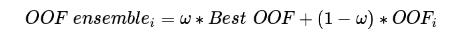

In [13]:
RES = 100
TOL = 0.0003
best_oof_loc = np.argmin(score)
best_oof_score = min(score)
print("best score:", best_oof_score, "best file:",best_oof_loc)

best score: 0.41026785398718674 best file: 50


In [14]:
all_weights = []
files_used = []

## run for each file

best_ensemble = train_preds[best_oof_loc]
best_ensemble_score = best_oof_score


# multiple runs: using the best ensemble from the previous run
for k in range ( 100 ) :
    print(f"##### Run {k} #####")
    
    # Run for each file
    for j in range(train_preds.shape[1]):

        #reset 
        best_weight = 0

        # Run for the file against each weight/ensemble
        for i in range(RES): 
            tmp_ensemble = i/RES *  train_preds[j] + (1-i/RES)*best_ensemble 
            tmp_score = log_loss(y,tmp_ensemble)
            if tmp_score < best_ensemble_score:
                print(f"file {j}: {tmp_score:.8f} beats: {best_ensemble_score:.8f}, with weight {i/RES}")
                best_weight = i/RES
                best_ensemble = tmp_ensemble
                best_ensemble_score = tmp_score

        #save file and weight
        if best_weight !=0:
            files_used.append(j)
            all_weights.append(best_weight)

                
    # STOP IF DECREASE IS GREATER THAN TOL
    diff = tmp_score- best_ensemble_score
    if diff>=TOL: 
        print(); print(f'No major change in metric. Stopping with difference of {diff}')
        break

##### Run 0 #####
file 51: 0.41026283 beats: 0.41026785, with weight 0.01
file 51: 0.41025398 beats: 0.41026283, with weight 0.02
file 51: 0.41024358 beats: 0.41025398, with weight 0.03
file 51: 0.41023463 beats: 0.41024358, with weight 0.04
file 51: 0.41023048 beats: 0.41023463, with weight 0.05

No major change in metric. Stopping with difference of 0.108611204181908


In [15]:
print('Models used',files_used)
print('weights used',all_weights)
print('Best ensemble score of = %.4f'%best_ensemble_score)

Models used [51]
weights used [0.05]
Best ensemble score of = 0.4102


## Apply to Test data

In [16]:
best_test = test_preds[best_oof_loc]

for f,w in zip(files_used, all_weights):
    print(f"Ensembling file {f}, with weight {w}")
    best_test = w * test_preds[f] + (1-w)*best_test
best_test

Ensembling file 51, with weight 0.05


0        0.561665
1        0.652071
2        0.206074
3        0.425817
4        0.062279
           ...   
19995    0.190469
19996    0.336160
19997    0.476009
19998    0.470500
19999    0.355816
Length: 20000, dtype: float64

## Submission 

In [17]:
sub_hill = pd.read_csv("../input/tabular-playground-series-nov-2022/sample_submission.csv",index_col = 0)
sub_hill["pred"] =0
sub_hill["pred"]=best_test.values
sub_hill.to_csv("hill_climbing.csv")
sub_hill

,pred
id,
20000,0.561665
20001,0.652071
20002,0.206074
20003,0.425817
20004,0.062279
...,...
39995,0.190469
39996,0.336160
39997,0.476009


# 2. Scipy Minimize
Adapted from [Laurent Pourchot's notebook ](https://www.kaggle.com/code/pourchot/stacking-with-scipy-minimize)

In [18]:
def objective(w):
    
    weighted_pred = np.zeros(len(y))
    for i in range(train_preds.shape[1]):
        
        weighted_pred += w[i]* train_preds[i]
                  
    return log_loss(y, weighted_pred.values)

In [19]:
starting_values = 0
cons = ({'type':'eq','fun':lambda x: 1-sum(x)})
bounds = [(0,1)]* train_preds.shape[1]  # create bounds for each pred

def optimize(METHOD):
    res = minimize(
                objective, 
                x0= starting_values, 
                method=METHOD, 
                bounds=bounds, 
                constraints=cons,
                tol = TOL
                  )
    return res['fun'], res['x']

In [20]:
log_loss_Nelder, weights_Nelder = optimize('Nelder-Mead')
test_Nelder = np.zeros (len(test_preds))

for i in range(test_preds.shape[1]):
    test_Nelder += weights_Nelder[i] * test_preds[i]
test_Nelder

0        0.590957
1        0.696364
2        0.242204
3        0.451611
4        0.063706
           ...   
19995    0.209061
19996    0.349554
19997    0.510479
19998    0.501941
19999    0.371240
Name: 0, Length: 20000, dtype: float64

In [21]:
log_loss_SLSQP, weights_SLSQP = optimize('SLSQP')
test_SLSQP = np.zeros (len(test_preds))

for i in range(test_preds.shape[1]):
    test_SLSQP += weights_SLSQP[i] * test_preds[i]
test_SLSQP

0        0.546516
1        0.659083
2        0.220107
3        0.492192
4        0.059903
           ...   
19995    0.174739
19996    0.351089
19997    0.483128
19998    0.489000
19999    0.367568
Name: 0, Length: 20000, dtype: float64

In [22]:
scipy_Nelder = pd.read_csv('../input/tabular-playground-series-nov-2022/sample_submission.csv',index_col = 0)
scipy_Nelder["pred"] = 0
scipy_Nelder["pred"] = test_Nelder.values
scipy_Nelder.to_csv("scipy_Nelder.csv")
scipy_Nelder

,pred
id,
20000,0.590957
20001,0.696364
20002,0.242204
20003,0.451611
20004,0.063706
...,...
39995,0.209061
39996,0.349554
39997,0.510479


In [23]:
scipy_SLSQP = pd.read_csv('../input/tabular-playground-series-nov-2022/sample_submission.csv',index_col = 0)
scipy_SLSQP["pred"] = 0
scipy_SLSQP["pred"] = test_SLSQP.values
scipy_SLSQP.to_csv("scipy_SLSQP.csv")
scipy_SLSQP

,pred
id,
20000,0.546516
20001,0.659083
20002,0.220107
20003,0.492192
20004,0.059903
...,...
39995,0.174739
39996,0.351089
39997,0.483128


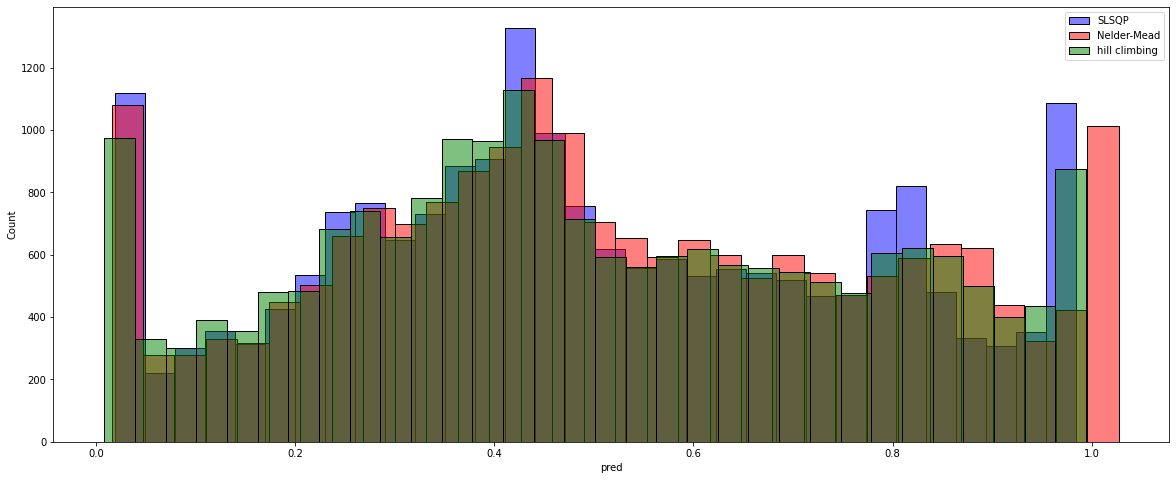

In [24]:
plt.figure(figsize = (20,8))
sns.histplot(scipy_SLSQP["pred"],color = "b" , alpha = 0.5, label = "SLSQP")
sns.histplot(scipy_Nelder["pred"],color = "red" , alpha = 0.5,label = "Nelder-Mead")
sns.histplot(sub_hill["pred"],color = "green" , alpha = 0.5,label = "hill climbing")
plt.legend()
plt.show()

# 3. Model Ensembling


In [25]:
from sklearn.model_selection import KFold
from sklearn.linear_model import SGDClassifier,LogisticRegression, LogisticRegressionCV

cv = KFold(n_splits= folds)
models = {"LogisticRegression":LogisticRegression(n_jobs=5000),
         "SGDClassifier":SGDClassifier(loss="log", penalty="elasticnet"),
         "LogisticRegressionCV":LogisticRegressionCV()}

In [26]:
# lin_scores = []
# preds = []
# for train_idx, val_idx in cv.split(train_preds,y):
    
#     X_train, X_val = train_preds.iloc[ train_idx, :], train_preds.iloc[val_idx, :]
#     y_train, y_val = y[train_idx], y[val_idx]
    
#     for model in models.items():  
#         print(model[0])
#         model[1].fit(X_train,y_train)
#         preds.append(model[1].predict_proba(test_preds)[:,1])
#         loss = log_loss(y_val,model[1].predict_proba(X_val)[:,1])
#         lin_scores.append(loss)
#         print(lin_scores)
        
        
    
# print("Mean Score",np.mean(lin_scores))
# lin_preds = np.mean(preds,axis =0)

In [27]:
lin_scores = []
preds = []
for train_idx, val_idx in cv.split(train_preds,y):
    
    X_train, X_val = train_preds.iloc[ train_idx, :], train_preds.iloc[val_idx, :]
    y_train, y_val = y[train_idx], y[val_idx]
    
    #model = LassoLarsCV(max_iter= 5000,normalize= True,eps=0.5)
    model = SGDClassifier(loss="log", penalty="elasticnet")
    
    model.fit(X_train,y_train)
    preds.append(model.predict_proba(test_preds)[:,1])
    loss = log_loss(y_val,model.predict_proba(X_val)[:,1])
    lin_scores.append(loss)
    
print("Mean Score",np.mean(lin_scores))
lin_preds = np.mean(preds,axis =0)

Mean Score 0.019814320077296933


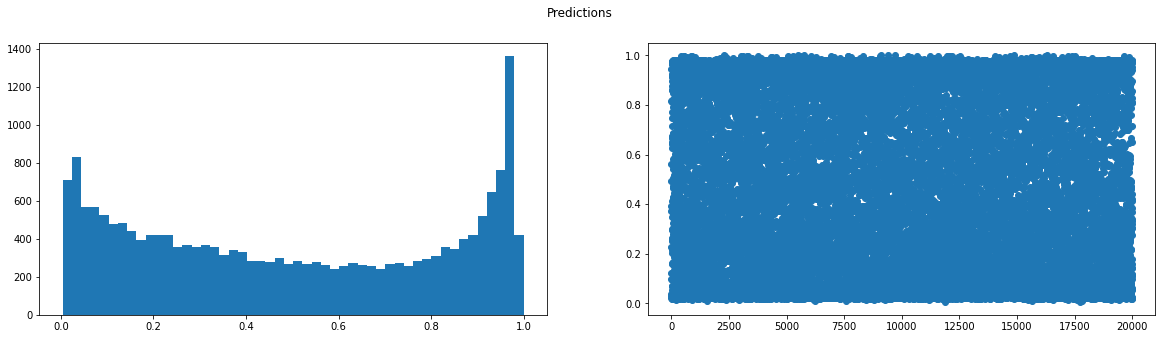

In [28]:
fig, ax = plt.subplots(1,2, figsize = (20,5))
ax[0].hist(lin_preds, bins = 50)
ax[1].scatter(test_preds.index,lin_preds )
fig.suptitle("Predictions")
plt.show()

In [29]:
model.coef_

array([[ 2.86297736e-01, -4.43558372e-02,  0.00000000e+00,
         0.00000000e+00,  1.85049614e-01, -2.19297984e-02,
         1.72321968e-02,  0.00000000e+00, -6.74934440e-03,
        -6.58387135e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.41780133e-02,  0.00000000e+00, -1.55949781e-01,
         0.00000000e+00,  0.00000000e+00,  8.23359494e-02,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.66059987e-02,  0.00000000e+00,  0.00000000e+00,
         1.22657867e-02, -1.32127603e-01,  2.23215133e-03,
         3.03784272e-01, -1.83443632e-02, -2.33863701e-02,
        -6.00122569e-02,  0.00000000e+00,  1.54730414e-01,
         1.10256079e-01,  1.25137495e-01,  1.30548384e-01,
         0.00000000e+00,  0.00000000e+00,  1.63287273e-01,
        -1.71750073e-01,  2.35169251e-01,  1.05521316e+0

In [30]:
lin_df = pd.read_csv('../input/tabular-playground-series-nov-2022/sample_submission.csv',index_col = 0)
lin_df["pred"] = 0
lin_df["pred"] = lin_preds
lin_df.to_csv("lin_model.csv")
lin_df

,pred
id,
20000,0.371983
20001,0.494227
20002,0.037582
20003,0.393509
20004,0.021222
...,...
39995,0.057826
39996,0.273776
39997,0.305663


# 4. Weighted Ensemble

In [31]:
weighted_preds = np.zeros(len(y))

for k in range(test_preds.shape[1]):
    weighted_preds += (score[k] * test_preds.iloc[:,k] )
    
Weighted_Ensemble = weighted_preds/ sum(score)
Weighted_Ensemble

0        0.562960
1        0.666439
2        0.231580
3        0.434394
4        0.063758
           ...   
19995    0.200032
19996    0.334485
19997    0.488624
19998    0.480451
19999    0.354502
Name: 0, Length: 20000, dtype: float64

In [32]:
Weighted_df = pd.read_csv('../input/tabular-playground-series-nov-2022/sample_submission.csv',index_col = 0)
Weighted_df["pred"] = 0
Weighted_df["pred"] = Weighted_Ensemble.values
Weighted_df.to_csv("weighted_ensemble.csv")
Weighted_df

,pred
id,
20000,0.562960
20001,0.666439
20002,0.231580
20003,0.434394
20004,0.063758
...,...
39995,0.200032
39996,0.334485
39997,0.488624


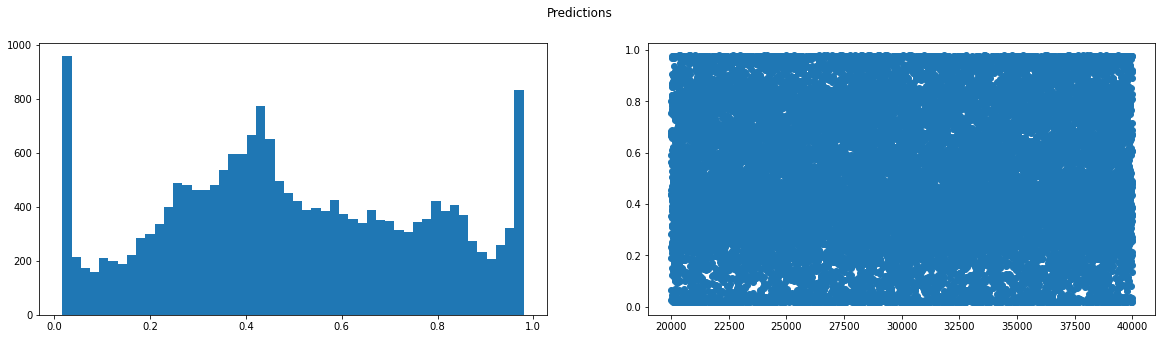

In [33]:
fig, ax = plt.subplots(1,2, figsize = (20,5))
ax[0].hist(Weighted_df, bins = 50)
ax[1].scatter(Weighted_df.index,Weighted_df )
fig.suptitle("Predictions")
plt.show()

# 5. Mean Ensemble

In [34]:
sum_preds = np.zeros(len(y))

for k in range(test_preds.shape[1]):
    sum_preds += test_preds.iloc[:,k]
    
mean_ensemble = sum_preds / test_preds.shape[1]

In [35]:
mean_df = pd.read_csv('../input/tabular-playground-series-nov-2022/sample_submission.csv',index_col = 0)
mean_df["pred"] = 0
mean_df["pred"] = mean_ensemble.values
mean_df.to_csv("mean_ensemble.csv")
mean_df

,pred
id,
20000,0.563509
20001,0.667463
20002,0.232014
20003,0.432138
20004,0.063110
...,...
39995,0.200594
39996,0.333945
39997,0.488606


# 📊 Visualize 📊

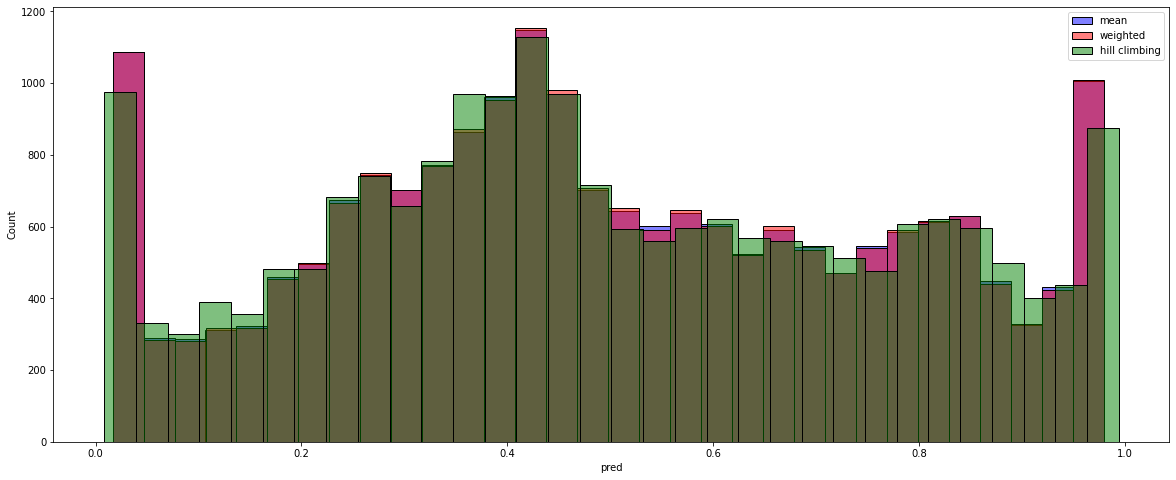

In [36]:
plt.figure(figsize = (20,8))
sns.histplot(mean_df["pred"],color = "b" , alpha = 0.5, label = "mean")
sns.histplot(Weighted_df["pred"],color = "red" , alpha = 0.5,label = "weighted")
sns.histplot(sub_hill["pred"],color = "green" , alpha = 0.5,label = "hill climbing")
#sns.histplot(lin_df["pred"],color = "orange" , alpha = 0.5,label = "linear model")
plt.legend()
plt.show()